In [1]:
from risk_experiment.symbolic_experiment.fit_probit import get_data, build_model
import arviz as az
import pandas as pd

/Users/gdehol/mambaforge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_label = 2

df = get_data(model_label=model_label)
model = build_model(model_label=model_label)
idata = az.from_netcdf(f'/data/ds-symbolicrisk/derivatives/risk_model/psychophysical/model{model_label}_samples.nc')

subject  trial_nr  onset      
100      225.0     1872.416877      5-7
         227.0     1882.094981      7-9
         229.0     1891.490411    19-28
         231.0     1901.817864     9-14
         233.0     1911.343296      7-9
                                  ...  
99       248.0     4280.560747    14-19
         250.0     4290.015506     9-14
         252.0     4299.364220     9-14
         254.0     4308.594834    14-19
         256.0     4317.861306     9-14
Name: n_safe_bin, Length: 14848, dtype: category
Categories (5, object): ['5-7' < '7-9' < '9-14' < '14-19' < '19-28']
subject  trial_nr  onset      
100      225.0     1872.416877      5-7
         227.0     1882.094981      7-9
         229.0     1891.490411    19-28
         231.0     1901.817864     9-14
         233.0     1911.343296      7-9
                                  ...  
99       248.0     4280.560747    14-19
         250.0     4290.015506     9-14
         252.0     4299.364220     9-14
         254.0     4

In [3]:
import scipy.stats as ss
def invprobit(x):
    return ss.norm.ppf(x)

def get_fake_data(data, group, model_label=None):

    unique_subjects = data.index.unique(level='subject')

    if group:
        fake_data = pd.MultiIndex.from_product([unique_subjects[:1], [0, 1], data['n_safe_bin'].unique(), ['Risky first', 'Safe first']], names=['subject', 'log_risky_safe', 'n_safe_bin', 'order']).to_frame(index=False)
    else:
        fake_data = pd.MultiIndex.from_product([unique_subjects, [0,1], data['n_safe_bin'].unique(), ['Risky first', 'Safe first']], names=['subject', 'log_risky_safe', 'n_safe_bin', 'order']).to_frame(index=False)

    if model_label == 4:
        fake_data['n_safe'] = fake_data['n_safe_bin'].apply(lambda x: np.mean(np.array(x.split('-'), dtype=float)))


    return fake_data

def extract_intercept_gamma(trace, model, data, group=False, model_label=None):

    fake_data = get_fake_data(data, group, model_label=model_label)

    pred = model.predict(trace, 'response_params', fake_data, inplace=False, include_group_specific=not group)['posterior']['p']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred

    pred0 = pred.xs(0, 0, 'log_risky_safe')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'log_risky_safe')) - intercept

    intercept = intercept.droplevel(0, 1)#,), keys=['intercept'], axis=1)
    gamma = gamma.droplevel(0, 1)#,), keys=['gamma'], axis=1)

    return intercept, gamma

def get_info(model_label, group=True):

    model = build_model(model_label=model_label)
    df = get_data(model_label=model_label)

    idata = az.from_netcdf(f'/data/ds-symbolicrisk/derivatives/risk_model/psychophysical/model{model_label}_samples.nc')
    intercept, gamma = extract_intercept_gamma(idata, model, df, group=group, model_label=model_label)
    rnp = np.clip(np.exp(intercept/gamma), 0, 1)
    rnp = rnp.stack([0, 1]).to_frame('rnp')
    intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamma.stack([0, 1]).to_frame('gamma')

    return pd.concat([intercept, gamma, rnp], axis=1)

In [4]:
df['bin(risky/safe)'] = pd.cut(df['log(risky/safe)'], bins=9)
df['bin(risky/safe)'] = df['bin(risky/safe)'].apply(lambda x: x.mid)

In [18]:
pred = model.predict(idata.sel(draw=slice(None, None, 20)), data=df.reset_index(), inplace=False, kind='response')

# pred = pred.posterior['p'].to_dataframe()

pred = pred.posterior_predictive['chose_risky'].to_dataframe()

pred = pred.unstack([0, 1])

pred.index = df.index

pred = pred.droplevel(0, axis=1).stack([0, 1]).to_frame('chose_risky_pred')
pred = pred.join(df)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/307100628.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pred = pred.droplevel(0, axis=1).stack([0, 1]).to_frame('chose_risky_pred')


In [19]:
tmp = pred.groupby(['subject', 'n_safe_bin', 'Order', 'chain', 'draw', 'bin(risky/safe)'])[['chose_risky', 'chose_risky_pred']].mean().groupby(['n_safe_bin', 'Order', 'bin(risky/safe)', 'chain', 'draw']).mean()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/3153920038.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = pred.groupby(['subject', 'n_safe_bin', 'Order', 'chain', 'draw', 'bin(risky/safe)'])[['chose_risky', 'chose_risky_pred']].mean().groupby(['n_safe_bin', 'Order', 'bin(risky/safe)', 'chain', 'draw']).mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/3153920038.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = pred.groupby(['subject', 'n_safe_bin', 'Order', 'chain', 'draw', 'bin(risky/safe)'])[['chose_risky', 'chose_risky_pred']].mean().groupby(['n_sa

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/3881505089.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hdi = data.groupby(x)[y].apply(lambda x: get_hdi(x)).unstack()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/3881505089.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hdi = data.groupby(x)[y].apply(lambda x: get_hdi(x)).unstack()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/3881505089.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain c

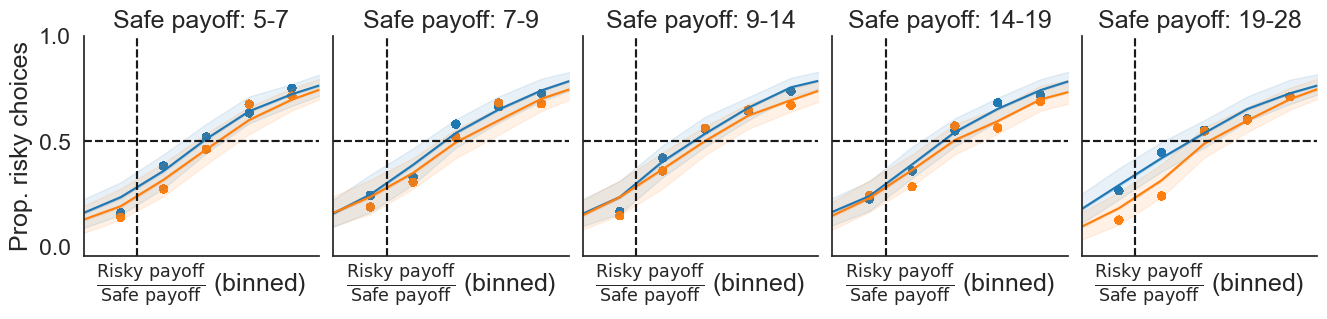

In [20]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

palette = sns.color_palette()
sns.set(style='white', font_scale=1.5)
sns.set_palette(palette)

def get_hdi(x, hdi_prob=0.95):
    return pd.Series(az.hdi(x.values, hdi_prob=hdi_prob), index=['hdi_lower', 'hdi_upper']).T

def plot_hdi(data, x, y, **kwargs):
    import matplotlib.pyplot as plt
    hdi = data.groupby(x)[y].apply(lambda x: get_hdi(x)).unstack()
    plt.fill_between(x=data[x].unique(), y1=hdi['hdi_lower'], y2=hdi['hdi_upper'], **kwargs)

g = sns.FacetGrid(tmp.reset_index(), col='n_safe_bin', hue='Order', hue_order=['Safe first', 'Risky first'], height=5., aspect=1.)

g.map_dataframe(sns.scatterplot, x='bin(risky/safe)', y='chose_risky', edgecolor='none')
g.map_dataframe(sns.lineplot, x='bin(risky/safe)', y='chose_risky_pred')



g.map(plt.axvline, x=np.log(1/.55), color='k', ls='--')
g.map(plt.axhline, y=.5, color='k', ls='--')
g.map_dataframe(plot_hdi, x='bin(risky/safe)', y='chose_risky_pred', alpha=0.1)

#Force panels to have equal aspect ratio


g.set(xlim=(np.log(1.5), np.log(3.5)), xlabel='', yticks=[0, .5, 1], ylabel='Prop. risky choice', xticks=[])
g.set(xlabel=r'$\frac{\mathrm{Risky\ payoff}}{\mathrm{Safe\ payoff}}$ (binned)', ylabel='Prop. risky choices')

g.set_titles('Safe payoff: {col_name}')

plt.tight_layout()


g.fig.set_size_inches(13, 3)
g.savefig('/data/ds-risk/derivatives/figures/ppcs_symbolic.pdf', bbox_inches='tight')

In [9]:
pars = get_info(model_label=2, group=True)
pars

subject  trial_nr  onset      
100      225.0     1872.416877      5-7
         227.0     1882.094981      7-9
         229.0     1891.490411    19-28
         231.0     1901.817864     9-14
         233.0     1911.343296      7-9
                                  ...  
99       248.0     4280.560747    14-19
         250.0     4290.015506     9-14
         252.0     4299.364220     9-14
         254.0     4308.594834    14-19
         256.0     4317.861306     9-14
Name: n_safe_bin, Length: 14848, dtype: category
Categories (5, object): ['5-7' < '7-9' < '9-14' < '14-19' < '19-28']
subject  trial_nr  onset      
100      225.0     1872.416877      5-7
         227.0     1882.094981      7-9
         229.0     1891.490411    19-28
         231.0     1901.817864     9-14
         233.0     1911.343296      7-9
                                  ...  
99       248.0     4280.560747    14-19
         250.0     4290.015506     9-14
         252.0     4299.364220     9-14
         254.0     4

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/328348986.py:48: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  rnp = rnp.stack([0, 1]).to_frame('rnp')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/328348986.py:49: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamma.stack([0, 1]).to_frame('gamma')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/328348986.py:49: FutureWarning: The previous implementation of stack is deprecated and will be removed in a fut

intercept     gamma       rnp
subject n_safe_bin order       chain draw                               
100     5-7        Risky first 0     0     -3.168280  3.180508  0.369297
                                     1     -2.898629  2.878428  0.365307
                                     2     -2.809249  2.721993  0.356274
                                     3     -2.826973  2.835768  0.369022
                                     4     -2.803457  2.981239  0.390485
...                                              ...       ...       ...
        14-19      Safe first  3     1995  -3.086131  3.233491  0.385033
                                     1996  -3.281961  3.365604  0.377137
                                     1997  -3.017445  3.187448  0.388033
                                     1998  -2.977102  3.564911  0.433826
                                     1999  -3.209086  3.695970  0.419679

[80000 rows x 3 columns]

In [10]:
rnp = pars['rnp'].to_frame('rnp')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86169/4063040937.py:26: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  g = sns.catplot(data=diff.reset_index(), col='n_safe_bin', x='difference', color='k', kind='point', height=1.8, aspect=1., join=False, errorbar=get_hdi)


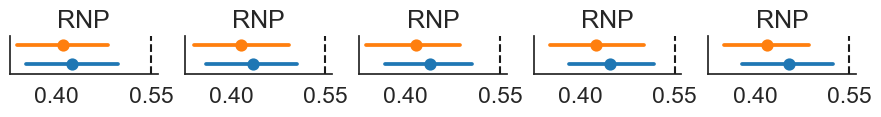

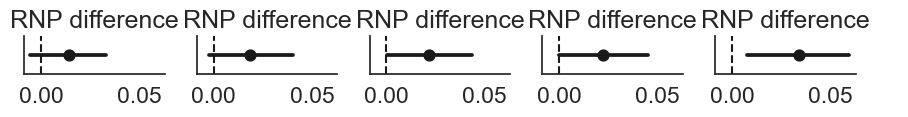

In [16]:
palette = sns.color_palette()
sns.set(style='white', font_scale=1.5)
sns.set_palette(palette)


def get_hdi(x, hdi_prob=0.95):
    return pd.Series(az.hdi(x.values, hdi_prob=hdi_prob), index=['hdi_lower', 'hdi_upper']).T

g = sns.FacetGrid(rnp.reset_index(), col='n_safe_bin', height=1.8, aspect=1., )
g.map_dataframe(sns.pointplot, x='rnp', errorbar=get_hdi, hue='order', dodge=.1, hue_order=['Safe first', 'Risky first'], legend=False,
                palette=sns.color_palette()[:2])

g.map(plt.axvline, x=.55, c='k', ls='--', zorder=10)
g.set(ylim=(-.1, .1))

g.set_titles('RNP')

g.set(xticks=[.4, .55], xlabel=None)

tmp = rnp.unstack('order').droplevel(0, 1)

diff = (tmp['Safe first'] - tmp['Risky first']).to_frame('difference')

g.savefig('/data/ds-risk/derivatives/figures/rnp_symbolic.pdf', bbox_inches='tight')

g = sns.catplot(data=diff.reset_index(), col='n_safe_bin', x='difference', color='k', kind='point', height=1.8, aspect=1., join=False, errorbar=get_hdi)

g.map(plt.axvline, x=0, color='k', ls='--')

# g.set(xlim=(-.1, .1), xlabel='RNP difference (Safe first - Risky first)', yticks=[])
g.set_titles('RNP difference')
g.set(xlabel='', xticks=[0.0, 0.05])

# sns.despine(bottom=True, left=True)
g.savefig('/data/ds-risk/derivatives/figures/rnp_difference_symbolic.pdf', bbox_inches='tight')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_3551/293310733.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


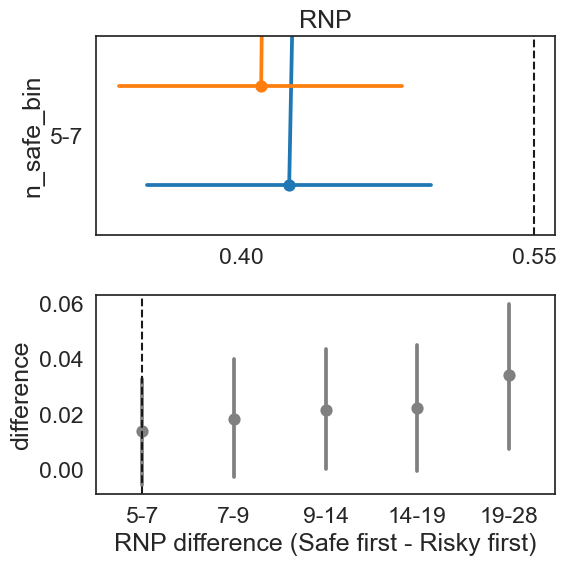

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=False, height_ratios=[1, 1])

# Plot 1: Pointplot of RNP by order
sns.pointplot(
    data=rnp.reset_index(),
    x='rnp',
    y='n_safe_bin',
    hue='order',
    dodge=.1,
    hue_order=['Safe first', 'Risky first'],
    palette=sns.color_palette()[:2],
    errorbar=get_hdi,
    ax=ax1,
    legend=False
)
ax1.axvline(x=.55, c='k', ls='--', zorder=10)
ax1.set(ylim=(-.1, .1), xticks=[.4, .55], xlabel=None, title='RNP')

# Plot 2: Difference plot
diff = (tmp['Safe first'] - tmp['Risky first']).to_frame('difference')
sns.pointplot(
    data=diff.reset_index(),
    x='n_safe_bin',
    y='difference',
    color='gray',
    errorbar=get_hdi,
    ax=ax2,
    join=False
)
ax2.axvline(x=0, color='k', ls='--')
ax2.set(xlabel='RNP difference (Safe first - Risky first)', title='')

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
difference = tmp.groupby('n_safe_bin')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_3551/4042807961.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  difference = tmp.groupby('n_safe_bin')
